In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = 500

In [28]:
import matplotlib as mlp
mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

### Загрузим датасет с машинами. Цель - верно восстанавливать для каждой из них цену продажи!

In [29]:
data = pd.read_csv('autos.csv')

data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [30]:
### Колонка с тергетом - "selling price"

X = data.drop("selling_price", axis=1)
y = data["selling_price"]

### Будем замерять MSLE!
### Поэтому прологарифмируем таргет
### А после оптимизируем MSE

y = y.apply(np.log1p)

In [31]:
### Разделим выборку на трейн и тест!

from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

__Задание__ 

Реализуйте свой MeanTargetEncoder с добавленем некоторого шума!

Однажды в лекционном материале, обсуждая счетчики, мы говорили с вами о том, что из-за них модели могут переобучаться. Один из способов бороться с этим - валидировать расчеты среднего таргета (стратегия отложенной выборки / расчеты на кросс-валидации). Но есть еще проще!

Можно просто к значению счетчика добавить случайный шум (зашумить данные)!

Напомним, что рассчитываться новые признаки должны по такой формуле:

$$
g_j = \frac{\sum_{i=1}^{l} [f_j(x) = f_j(x_i)]}{l} + C * \epsilon
$$



Пусть шум будет случайной величиной из нормального стандартного распределения, то есть $\epsilon \sim N(0, 1) $, а $ C = 0.006$.

Создавая свой класс-трансформер, наследуйтесь от классов `BaseEstimator, TransformerMixin` из `sklearn.base`. Трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики нужно считать только по обучающей выборке в методе `fit`. Ваш трансформер должен принимать при инициализации список из категориальных признаков и список из числовых признаков. 

Если для какого-то признака в тестовой выборке отсутствует значение, трансформер должен поставить там 0.

На выходе должен получиться датасет того же размера с измененными категориальными признаками.

Класс MeanTargetEncoderNoise должен иметь следующую сигнатуру:



Разделите колонки на вещественные и категориальные. Приведите все категориальные колонки к типу `object`.

Далее применим наш кодировщик к `X_train, X_test`, так же как например мы применяем `StandardScaler`, чтобы проверить работоспособность нашего класса. Установите зерно датчика случайный чисел `np.random.seed(1)`.

После того, как вы изменили обучающую и тестовую выборки, сохраните первые 10 строк полученного промежуточного датафрейма обучающей выборки (`X_train`) в файл в формате csv с сепаратором `;`. Не забудьте индекс. Отправьте полученный файл в форму ниже.

Список колонок которые должны быть в файле для сдачи:
```py
cols = [
    "km_driven",
    "name",
    "year",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]
```

### Ваше решение


Разделение колонок на категориальные и числовые.

In [33]:
object_cols = ['name', 'year', 'fuel', 'seller_type', 'transmission', 'owner']
num_cols = ['km_driven']

X.head()

,name,year,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,141000,Diesel,Individual,Manual,Second Owner


In [34]:
X.dtypes

name            object
year             int64
km_driven        int64
fuel            object
seller_type     object
transmission    object
owner           object
dtype: object

Реализация класса MeanTargetEncoderNoise.

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin

class MeanTargetEncoderNoise(BaseEstimator, TransformerMixin):
    
    def __init__(self, categorical, numeric):
        
        ### Your code is here
        self.categorical = categorical
        self.numeric = numeric
        self.C = 0.006
    
    def fit(self, X, y):

        ### Your code is here
        X = X.copy()
        y = y.copy()

        for col in self.categorical:
            X[col] = X[col].astype(object)
            
        # словарь: {col: {category: mean_target}}
        self.target_means_ = {}
        
        
        for col in self.categorical:
            self.target_means_[col] = y.groupby(X[col]).mean()
        

        return self
        
    def transform(self, df):
        
        ### Your code is here
        temp = df.copy()

        for col in self.categorical:
            noise = np.random.normal(0, 1, size=len(temp))

            temp[col] = (
                temp[col]
                .map(self.target_means_[col])
                .fillna(0)
                +self.C * noise
            )

        
        return temp

Проверка работы трансформера.

In [36]:
np.random.seed(1)
transformer = MeanTargetEncoderNoise(categorical=object_cols, numeric=num_cols)

transformer.fit(X_train, y_train)

train = transformer.transform(X_train)
test = transformer.transform(X_test)

train.head(10)

,name,year,km_driven,fuel,seller_type,transmission,owner
3294,13.478865,13.430921,50000,13.088541,12.609423,13.759065,12.964161
2290,12.111783,11.901925,70000,12.457036,12.620399,13.777324,12.962823
874,12.298593,13.336935,50000,12.455670,12.616451,12.645775,12.984195
1907,12.477658,13.055335,92198,12.463101,13.152012,12.637086,12.452642
3244,12.397144,12.857059,3240,12.454647,12.614863,12.627399,12.471970
1089,12.676751,13.438608,10000,12.455622,13.131947,12.644854,12.969999
3902,11.707359,11.497869,90000,12.449646,12.623791,12.639662,11.873113
2215,11.117254,11.502353,79000,12.452455,12.611637,12.632816,12.461447
3862,13.173893,13.339740,99700,13.085635,12.615428,12.632198,12.965374
705,12.997664,12.239908,124000,13.095024,12.616603,12.633892,12.460185


In [37]:
### сохраняем файл
train.head(10).to_csv('train.csv', sep=';', index=False)

Обучите несколько деревьев, перебирая максимальную глубину алгоритма из списка `max_depth_list`, а остальные параметры оставьте дефолтными. Выведите лучшее значение гиперпараметра. Постройте график зависимости MSLE на тестовой выборке от значения гиперпараметра. Воспользуйтесь `Pipeline` без `GridSearch`. Проделайте то же самое с `min_samples_split`, `min_impurity_decrease`, `max_leaf_nodes`. (по 2б на каждый параметр)

In [38]:
max_depth_list = [3, 5, 8, 12]
min_samples_split_list = [10, 50, 100, 500]
min_impurity_decrease_list = [0, 0.1, 0.15, 0.2]
max_leaf_nodes_list = [100, 200, 500]

[0.8173543461077388, 1.2040091303658813, 1.3453560422529565, 2.0033894200869073]


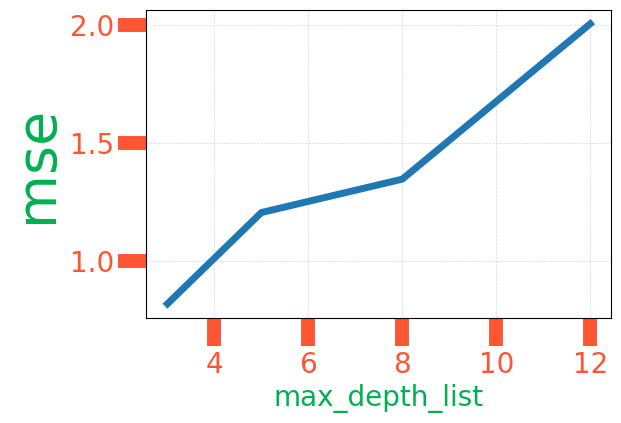

In [49]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

np.random.seed(1)

### Your code is here
mse_res = []

itself = max_depth_list
name = 'max_depth_list'

for x in itself:
    tree = DecisionTreeRegressor(max_depth=x)
    tree.fit(train, y_train)
    y_pred = tree.predict(test)
    res = mse(y_test, y_pred)
    mse_res.append(res)
print(mse_res)
fig = plt.figure()
fig.set_size_inches(6, 4)
x = itself
y = mse_res
plt.plot(x, y)
plt.xlabel(name, fontsize=20, color = '#00B050')
plt.ylabel('mse', fontsize=40, color='#00B050')
plt.tick_params(colors='#FF5533', labelsize=20,
                length=20, width=10)
plt.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
plt.show()

[1.3546730121918857, 1.2034211693797903, 0.9385670264921232, 0.8293581828257125]


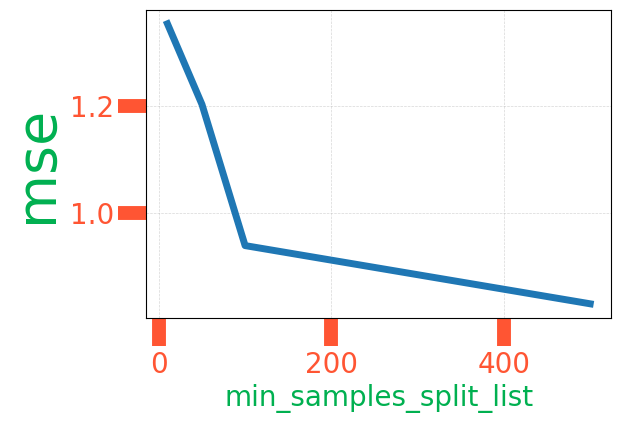

In [53]:
np.random.seed(1)

### Your code is here
mse_res = []

itself = min_samples_split_list
name = 'min_samples_split_list'

for x in itself:
    tree = DecisionTreeRegressor(min_samples_split=x)
    tree.fit(train, y_train)
    y_pred = tree.predict(test)
    res = mse(y_test, y_pred)
    mse_res.append(res)
print(mse_res)
fig = plt.figure()
fig.set_size_inches(6, 4)
x = itself
y = mse_res
plt.plot(x, y)
plt.xlabel(name, fontsize=20, color = '#00B050')
plt.ylabel('mse', fontsize=40, color='#00B050')
plt.tick_params(colors='#FF5533', labelsize=20,
                length=20, width=10)
plt.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
plt.show()

[1.4229633014036291, 0.5238372818840186, 0.5238372818840318, 0.5238372818840289]


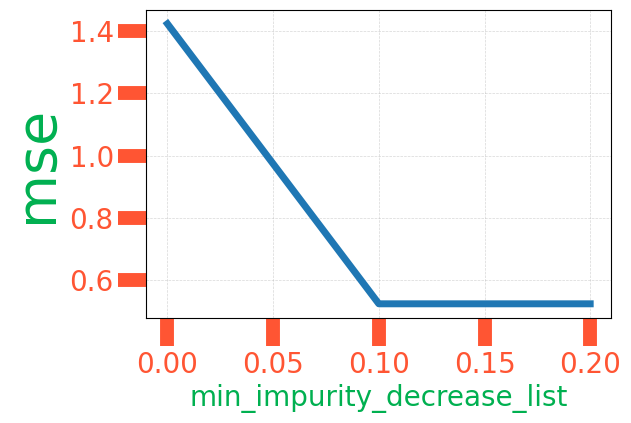

In [54]:
np.random.seed(1)

### Your code is here
mse_res = []

itself = min_impurity_decrease_list
name = 'min_impurity_decrease_list'

for x in itself:
    tree = DecisionTreeRegressor(min_impurity_decrease=x)
    tree.fit(train, y_train)
    y_pred = tree.predict(test)
    res = mse(y_test, y_pred)
    mse_res.append(res)
print(mse_res)
fig = plt.figure()
fig.set_size_inches(6, 4)
x = itself
y = mse_res
plt.plot(x, y)
plt.xlabel(name, fontsize=20, color = '#00B050')
plt.ylabel('mse', fontsize=40, color='#00B050')
plt.tick_params(colors='#FF5533', labelsize=20,
                length=20, width=10)
plt.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
plt.show()

[1.4229633014036291, 2.006719085529594, 1.3600533845155365]


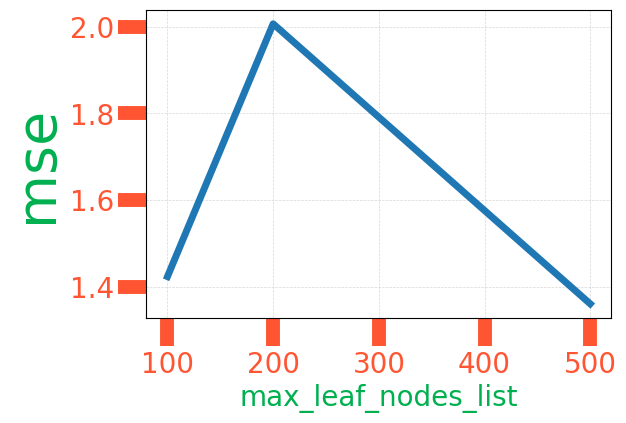

In [55]:
np.random.seed(1)

### Your code is here
mse_res = []

itself = max_leaf_nodes_list
name = 'max_leaf_nodes_list'

for x in itself:
    tree = DecisionTreeRegressor(max_depth=x)
    tree.fit(train, y_train)
    y_pred = tree.predict(test)
    res = mse(y_test, y_pred)
    mse_res.append(res)
print(mse_res)
fig = plt.figure()
fig.set_size_inches(6, 4)
x = itself
y = mse_res
plt.plot(x, y)
plt.xlabel(name, fontsize=20, color = '#00B050')
plt.ylabel('mse', fontsize=40, color='#00B050')
plt.tick_params(colors='#FF5533', labelsize=20,
                length=20, width=10)
plt.grid(True, alpha=0.5, linestyle='--', linewidth=0.5)
plt.show()

Подберите лучшую комбинацию параметров, используя `GridSearchCV` и набор массивов значений параметров из предыдущего задания. Для лучшей комбинации посчитайте MSLE на тестовой выборке. Получились ли лучшие параметры такими же, как если бы вы подбирали их по-отдельности при остальных гиперпараметрах по умолчанию (предыдущее задание)? (2б)

In [58]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.metrics import mean_squared_error

np.random.seed(1)

# Параметры должны соответствовать имени в Pipeline
param_grid = {
    "tree__max_depth": [3, 5, 8, 12],
    "tree__min_samples_split": [10, 50, 100, 500],
    "tree__min_impurity_decrease": [0, 0.1, 0.15, 0.2],
    "tree__max_leaf_nodes": [100, 200, 500]
}

pipe = Pipeline([
    ('scaler', MeanTargetEncoderNoise(categorical=object_cols, numeric=num_cols)),
    ('tree', DecisionTreeRegressor())
])

# Дополнительные настройки GridSearchCV
search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # использовать все ядра процессора
    verbose=1  # чтобы видеть прогресс
)

search.fit(X_train, y_train)

# Лучшие результаты
print(f"Лучшие параметры: {search.best_params_}")
print(f"Лучший score (MSE): {-search.best_score_:.4f}")

# Предсказание на тестовых данных
y_pred = search.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тесте: {test_mse:.4f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Лучшие параметры: {'tree__max_depth': 3, 'tree__max_leaf_nodes': 100, 'tree__min_impurity_decrease': 0.15, 'tree__min_samples_split': 500}
Лучший score (MSE): 0.5688
MSE на тесте: 0.5238
